In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch

# Tambahkan path root agar bisa mengimpor modul dari folder src/
sys.path.append(os.path.abspath(".."))

from src.preprocessing import prepare_wide_dataframe, get_transforms, TARGET_COLS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# 1. Load Data
DATA_DIR = "../data/csiro-biomass"
CSV_PATH = os.path.join(DATA_DIR, "train.csv")

df_wide = prepare_wide_dataframe(CSV_PATH)
print(f"Total gambar unik: {len(df_wide)}")
display(df_wide.head())

Total gambar unik: 357


,image_filename,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,State,Species,Pre_GSHH_NDVI,Height_Ave_cm
0,ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750,Tas,Ryegrass_Clover,0.62,4.6667
1,ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000,NSW,Lucerne,0.55,16.0000
2,ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500,WA,SubcloverDalkeith,0.38,1.0000
3,ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376,Tas,Ryegrass,0.66,5.0000
4,ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605,Tas,Ryegrass,0.54,3.5000


--- VISUALISASI HASIL AUGMENTASI GAMBAR ---


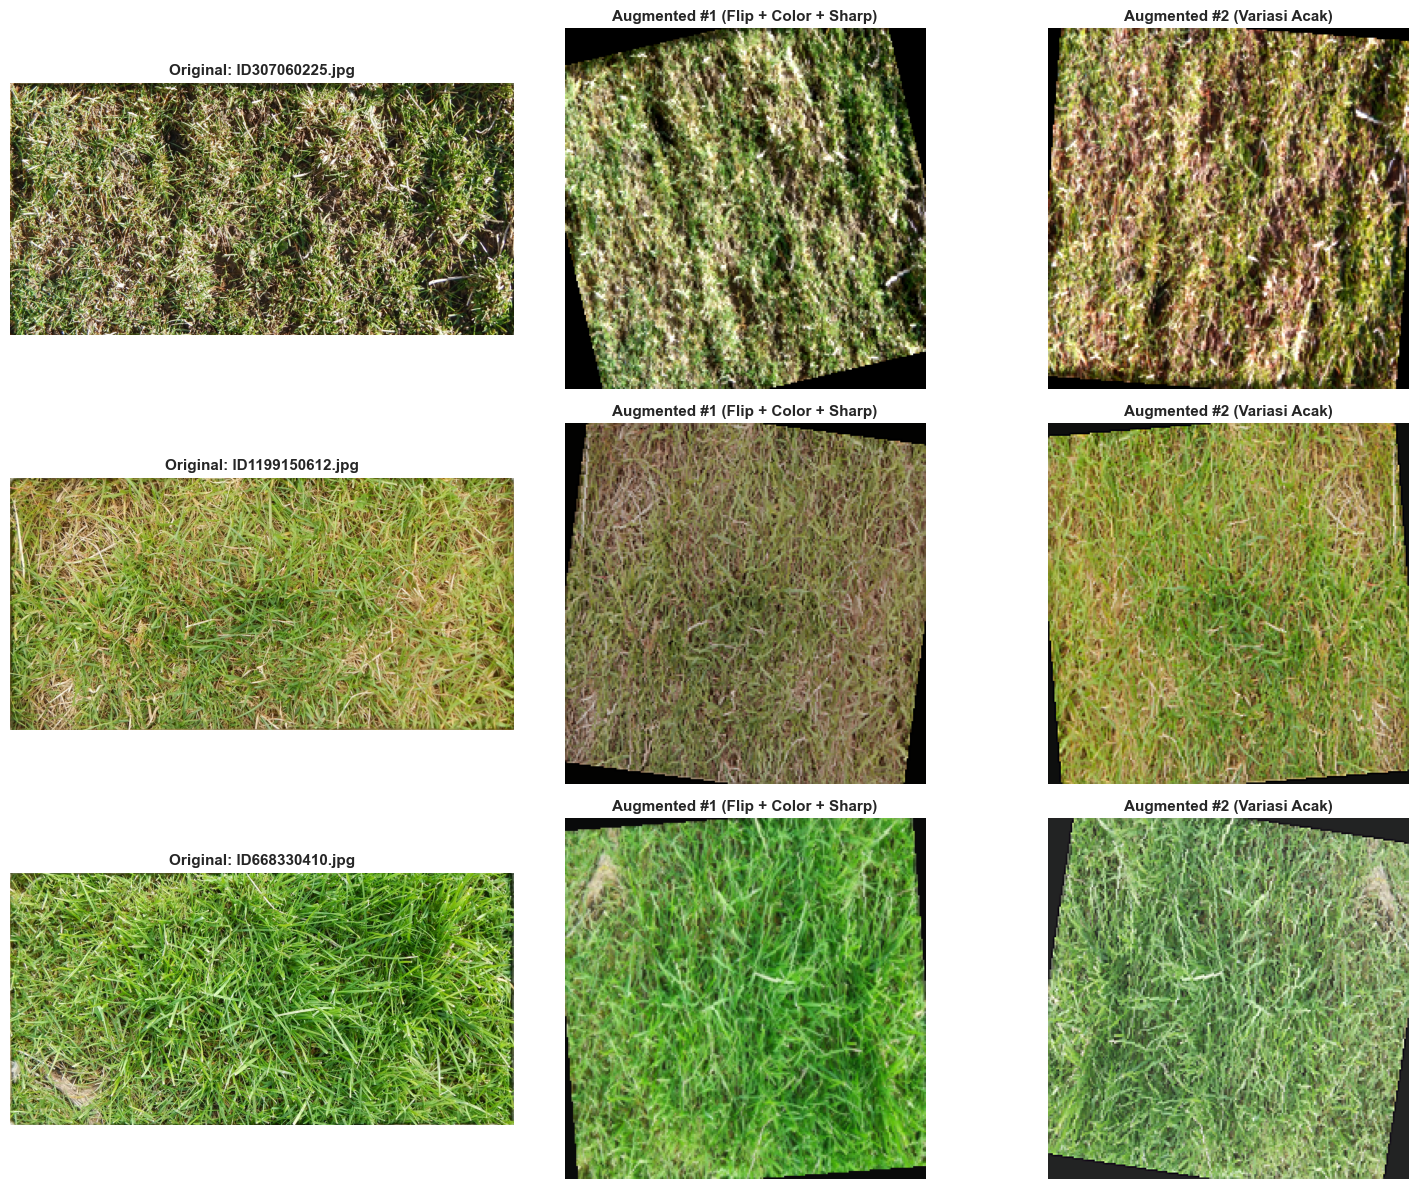

In [2]:
def denormalize_image(tensor_img):
    """Mengembalikan tensor yang dinormalisasi ImageNet ke skala piksel RGB (0-1)."""
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    
    img_np = tensor_img.numpy()
    img_np = (img_np * std) + mean  # Un-normalize
    img_np = np.clip(img_np, 0, 1)   # Clip nilai piksel agar berada di rentang [0, 1]
    img_np = np.transpose(img_np, (1, 2, 0)) # Ubah dari [C, H, W] ke [H, W, C]
    return img_np

def visualize_augmented_samples(df, base_dir, num_samples=3):
    sample_rows = df.sample(n=num_samples, random_state=42).reset_index(drop=True)
    
    train_transform = get_transforms(img_size=224, is_train=True)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    
    for idx, row in sample_rows.iterrows():
        img_name = row['image_filename']
        
        # Path gambar
        img_path = os.path.join(base_dir, "train_images", img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(base_dir, "train", img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(base_dir, img_name)
            
        raw_img = Image.open(img_path).convert("RGB")
        
        # Terapkan Augmentasi 2x dengan variasi acak yang berbeda
        aug_tensor_1 = train_transform(raw_img)
        aug_tensor_2 = train_transform(raw_img)
        
        aug_img_1 = denormalize_image(aug_tensor_1)
        aug_img_2 = denormalize_image(aug_tensor_2)
        
        # Plot Gambar Asli
        axes[idx, 0].imshow(raw_img)
        axes[idx, 0].set_title(f"Original: {img_name}", fontsize=11, fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Plot Augmentasi Versi 1
        axes[idx, 1].imshow(aug_img_1)
        axes[idx, 1].set_title("Augmented #1 (Flip + Color + Sharp)", fontsize=11, fontweight='bold')
        axes[idx, 1].axis('off')
        
        # Plot Augmentasi Versi 2
        axes[idx, 2].imshow(aug_img_2)
        axes[idx, 2].set_title("Augmented #2 (Variasi Acak)", fontsize=11, fontweight='bold')
        axes[idx, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

print("--- VISUALISASI HASIL AUGMENTASI GAMBAR ---")
visualize_augmented_samples(df_wide, DATA_DIR, num_samples=3)

In [ ]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(TARGET_COLS):
    raw_values = df_wide[col].values
    log_values = np.log1p(raw_values)
    
    # Histogram Skala Gram Asli
    plt.subplot(5, 2, 2*i + 1)
    sns.histplot(raw_values, kde=True, color='teal', bins=30)
    plt.title(f'Asli: {col} (Gram)', fontsize=10, fontweight='bold')
    plt.xlabel('Bobot (g)')
    
    # Histogram Skala Log
    plt.subplot(5, 2, 2*i + 2)
    sns.histplot(log_values, kde=True, color='coral', bins=30)
    plt.title(f'Log Transform: log1p({col})', fontsize=10, fontweight='bold')
    plt.xlabel('Nilai Skala Log')

plt.tight_layout()
plt.show()